In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
import seaborn as sns

# grafik stil veboyut ayarları
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# seed sabitleme
np.random.seed(42)

# Pandas gösterim ayarları
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 50)
pd.set_option("display.float_format", "{:.2f}".format)

In [3]:
n = 1000

sehir_listesi = [
    "İstanbul",
    "istanbul",
    "İSTANBUL ",
    "Ankara",
    "ANKARA",
    " ankara",
    "İzmir",
    "izmir",
]

df = pd.DataFrame(
    {
        "yas": np.random.randint(18, 70, size=n),
        "gelir": np.random.normal(35000, 8000, size=n).round(2),
        "sehir": np.random.choice(sehir_listesi, size=n),
        "abonelik_tipi": np.random.choice(
            ["Standart", "Premium", "Platin"], size=n, p=[0.6, 0.3, 0.1]
        ),
        "kayit_tarihi": pd.date_range(
            start="2024-01-01", periods=n, freq="D"
        ).strftime("%Y-%m-%d"),
        "aylik_harcama": np.random.uniform(100, 3000, size=n).round(2),
        "memnuniyet_puani": np.random.choice(
            [1, 2, 3, 4, 5], size=n, p=[0.05, 0.15, 0.3, 0.35, 0.15]
        ),
        "churn": np.random.choice([0, 1], size=n, p=[0.8, 0.2]),
    }
)

In [4]:
# NaN atanması
df.loc[np.random.choice(df.index, 40, replace=False), "gelir"] = np.nan
df.loc[np.random.choice(df.index, 30, replace=False), "yas"] = np.nan
df.loc[
    np.random.choice(df.index, 25, replace=False), "memnuniyet_puani"
] = np.nan

# gelir sütununa uç değerler (outlier)
df.loc[np.random.choice(df.index, 5, replace=False), "gelir"] = (
    np.random.uniform(500000, 1000000, 5)
)

# yaş sütununa mantık dışı değerler
df.loc[np.random.choice(df.index, 4, replace=False), "yas"] = [
    -5,
    -2,
    135,
    150,
]

# yinelenen satırların eklenmesi
duplikeler = df.sample(15, random_state=42)
df = pd.concat([df, duplikeler], ignore_index=True)

In [5]:
# Satır ve sütun sayısı
print("Boyut:", df.shape)

# Veri tipleri ve doluluk kontrolü
df.info()

# İlk, son ve rastgele satırlar
print("\nİlk 3 Satır:")
print(df.head(3))

print("\nSon 3 Satır:")
print(df.tail(3))

print("\nRastgele 3 Satır:")
print(df.sample(3))

Boyut: (1015, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1015 entries, 0 to 1014
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   yas               985 non-null    float64
 1   gelir             973 non-null    float64
 2   sehir             1015 non-null   object 
 3   abonelik_tipi     1015 non-null   object 
 4   kayit_tarihi      1015 non-null   object 
 5   aylik_harcama     1015 non-null   float64
 6   memnuniyet_puani  990 non-null    float64
 7   churn             1015 non-null   int64  
dtypes: float64(4), int64(1), object(3)
memory usage: 63.6+ KB

İlk 3 Satır:
    yas    gelir     sehir abonelik_tipi kayit_tarihi  aylik_harcama  \
0 56.00 22148.43    ANKARA      Standart   2024-01-01         165.04   
1 69.00 36627.71  istanbul      Standart   2024-01-02        1145.24   
2 46.00 28949.19    Ankara      Standart   2024-01-03        2372.84   

   memnuniyet_puani  churn  
0           

--- Eksik Değer Tablo ---
                  Eksik_Sayisi  Eksik_Yuzdesi  Benzersiz_Deger_Sayisi
yas                         30           2.96                      56
gelir                       42           4.14                     960
sehir                        0           0.00                       8
abonelik_tipi                0           0.00                       3
kayit_tarihi                 0           0.00                    1000
aylik_harcama                0           0.00                     999
memnuniyet_puani            25           2.46                       5
churn                        0           0.00                       2


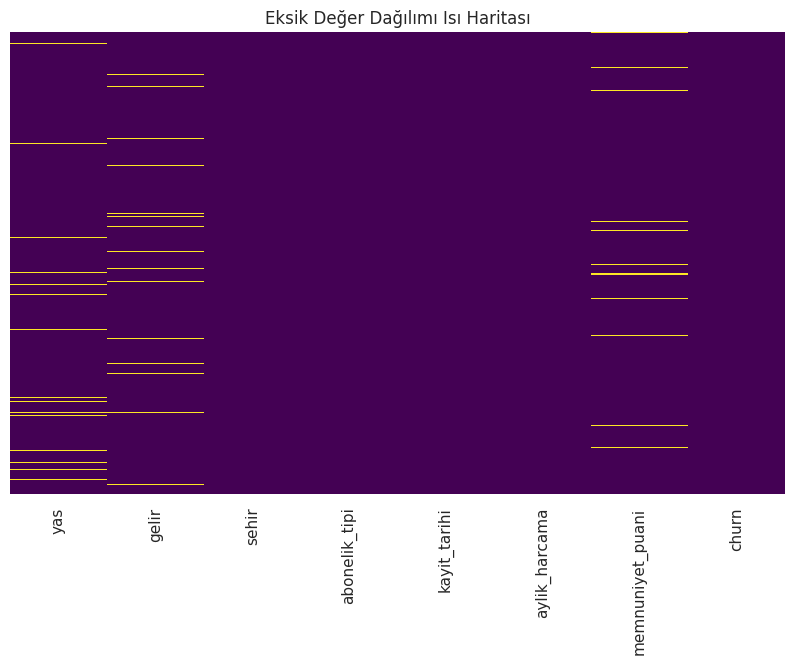

In [6]:
# eksik değer
eksik_ozet = pd.DataFrame(
    {
        "Eksik_Sayisi": df.isna().sum(),
        "Eksik_Yuzdesi": (df.isna().mean() * 100).round(2),
        "Benzersiz_Deger_Sayisi": df.nunique(),
    }
)
print("--- Eksik Değer Tablo ---")
print(eksik_ozet)

# heatmap
sns.heatmap(df.isna(), cbar=False, cmap="viridis", yticklabels=False)
plt.title("Eksik Değer Dağılımı Isı Haritası")
plt.show()

In [7]:
print("duplicate satır sayısı:", df.duplicated().sum())

duplicate satır sayısı: 15


In [8]:
print("Temizlik Öncesi:")
print(df["sehir"].value_counts())

# Küçük harfe çevirme boşlukları kırpma
df["sehir"] = (
    df["sehir"]
    .str.replace("İ", "i")
    .str.replace("I", "ı")
    .str.strip()
    .str.lower()
)

print("\nTemizlik Sonrası:")
print(df["sehir"].value_counts())

Temizlik Öncesi:
sehir
Ankara       151
 ankara      135
İstanbul     134
İSTANBUL     126
ANKARA       123
izmir        120
İzmir        116
istanbul     110
Name: count, dtype: int64

Temizlik Sonrası:
sehir
ankara      409
istanbul    370
izmir       236
Name: count, dtype: int64


In [9]:
anomali_yaslar = df[(df["yas"] < 0) | (df["yas"] > 100)]
print("Mantık Dışı Yaş Kayıtları:")
print(anomali_yaslar[["yas", "sehir", "gelir"]])

Mantık Dışı Yaş Kayıtları:
       yas     sehir    gelir
181 150.00    ankara 30652.60
640  -5.00    ankara 40109.84
782  -2.00  istanbul 36354.89
992 135.00    ankara 28720.81


In [10]:

print(df.describe())

# sayısal sütunlar için çarpıklık ve basıklık
sayisal_kolonlar = ["yas", "gelir", "aylik_harcama"]

for sutun in sayisal_kolonlar:
    veri = df[sutun].dropna()
    print(f"\n{sutun}:")
    print(f"  Skewness: {stats.skew(veri):.2f}")
    print(f"  Kurtosis: {stats.kurtosis(veri):.2f}")

         yas     gelir  aylik_harcama  memnuniyet_puani   churn
count 985.00    973.00        1015.00            990.00 1015.00
mean   43.95  39455.95        1521.47              3.40    0.20
std    15.79  56393.43         833.46              1.06    0.40
min    -5.00  11829.96         100.09              1.00    0.00
25%    31.00  30154.28         778.94              3.00    0.00
50%    44.00  35515.80        1519.24              3.00    0.00
75%    56.00  40672.03        2223.52              4.00    0.00
max   150.00 966066.96        2998.72              5.00    1.00

yas:
  Skewness: 0.39
  Kurtosis: 1.88

gelir:
  Skewness: 14.04
  Kurtosis: 203.50

aylik_harcama:
  Skewness: 0.02
  Kurtosis: -1.18


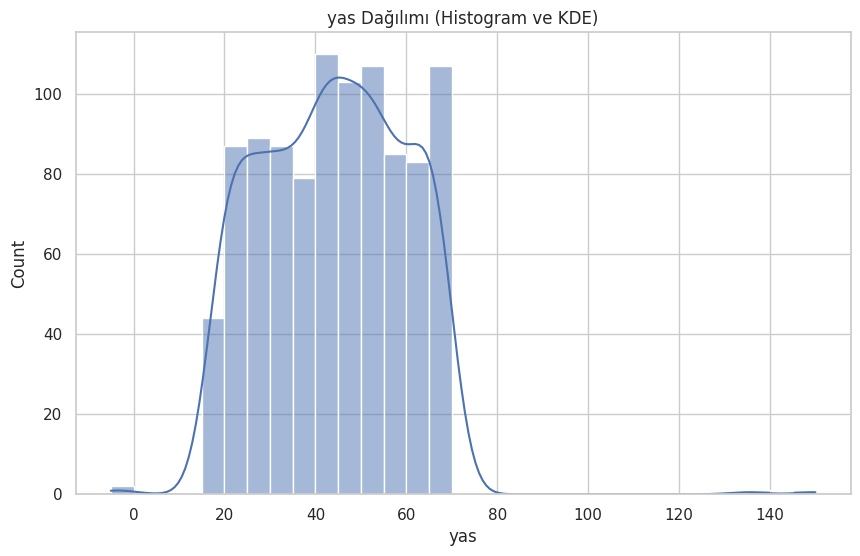

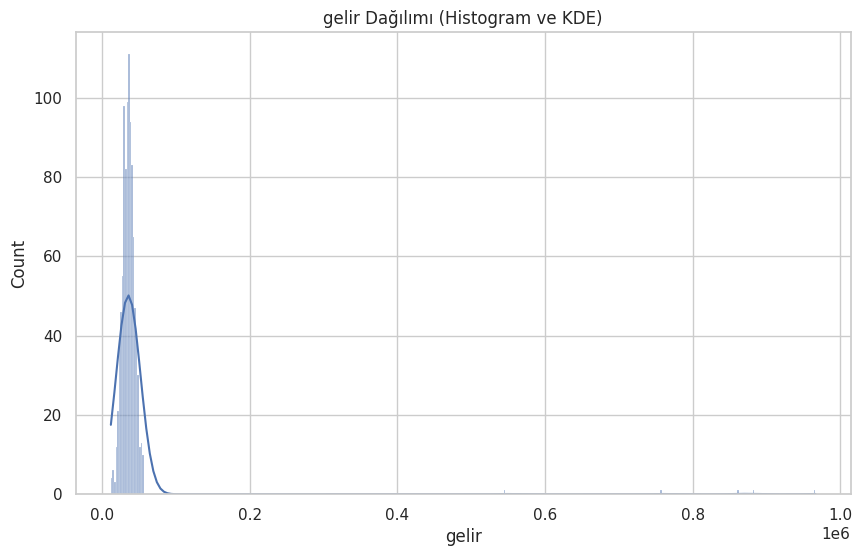

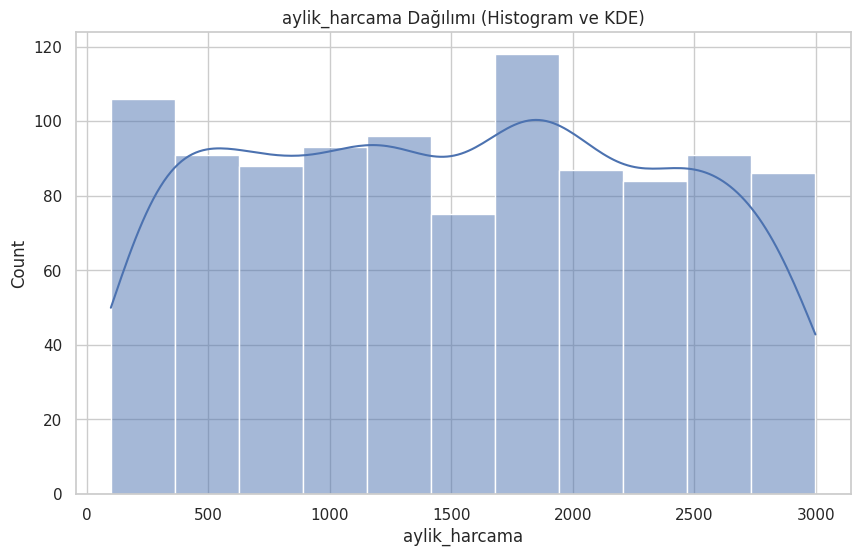

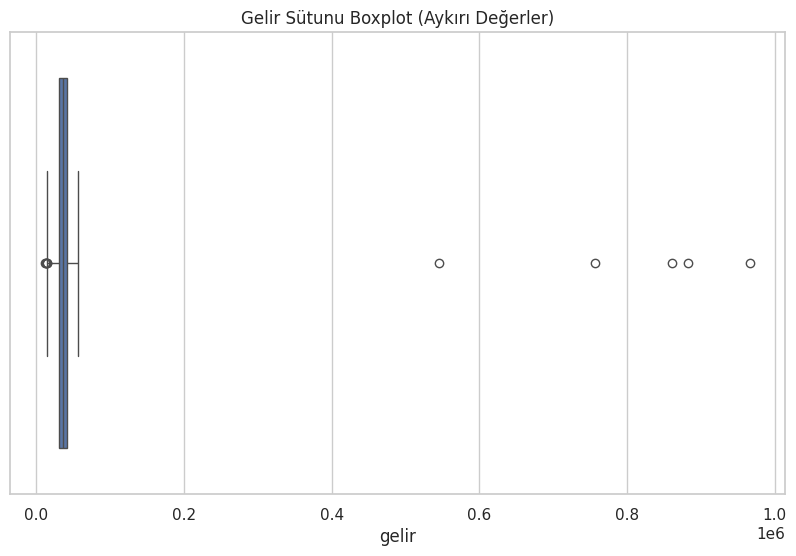

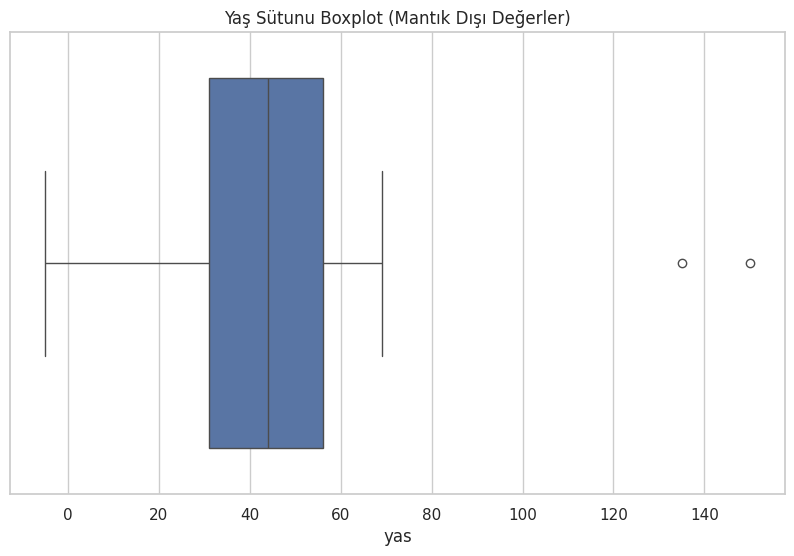

In [11]:
# Histogram ve KDE eğrileri
for sutun in ["yas", "gelir", "aylik_harcama"]:
    sns.histplot(df[sutun].dropna(), kde=True)
    plt.title(f"{sutun} Dağılımı (Histogram ve KDE)")
    plt.show()

# Boxplot ile aykırı değer gösterimi
sns.boxplot(x=df["gelir"].dropna())
plt.title("Gelir Sütunu Boxplot (Aykırı Değerler)")
plt.show()

sns.boxplot(x=df["yas"].dropna())
plt.title("Yaş Sütunu Boxplot (Mantık Dışı Değerler)")
plt.show()

In [12]:
kategorik_sutunlar = ["sehir", "abonelik_tipi", "memnuniyet_puani", "churn"]

for sutun in kategorik_sutunlar:
    print(f"\n--- {sutun} Yüzdesel Dağılımı (%) ---")
    print((df[sutun].value_counts(normalize=True, dropna=False) * 100).round(2))


--- sehir Yüzdesel Dağılımı (%) ---
sehir
ankara     40.30
istanbul   36.45
izmir      23.25
Name: proportion, dtype: float64

--- abonelik_tipi Yüzdesel Dağılımı (%) ---
abonelik_tipi
Standart   59.70
Premium    30.74
Platin      9.56
Name: proportion, dtype: float64

--- memnuniyet_puani Yüzdesel Dağılımı (%) ---
memnuniyet_puani
4.00   31.82
3.00   31.13
5.00   15.37
2.00   14.88
1.00    4.33
NaN     2.46
Name: proportion, dtype: float64

--- churn Yüzdesel Dağılımı (%) ---
churn
0   80.00
1   20.00
Name: proportion, dtype: float64


                   yas  gelir  aylik_harcama  memnuniyet_puani  churn
yas               1.00  -0.03           0.07              0.04  -0.01
gelir            -0.03   1.00          -0.00             -0.04  -0.04
aylik_harcama     0.07  -0.00           1.00             -0.05   0.01
memnuniyet_puani  0.04  -0.04          -0.05              1.00  -0.02
churn            -0.01  -0.04           0.01             -0.02   1.00


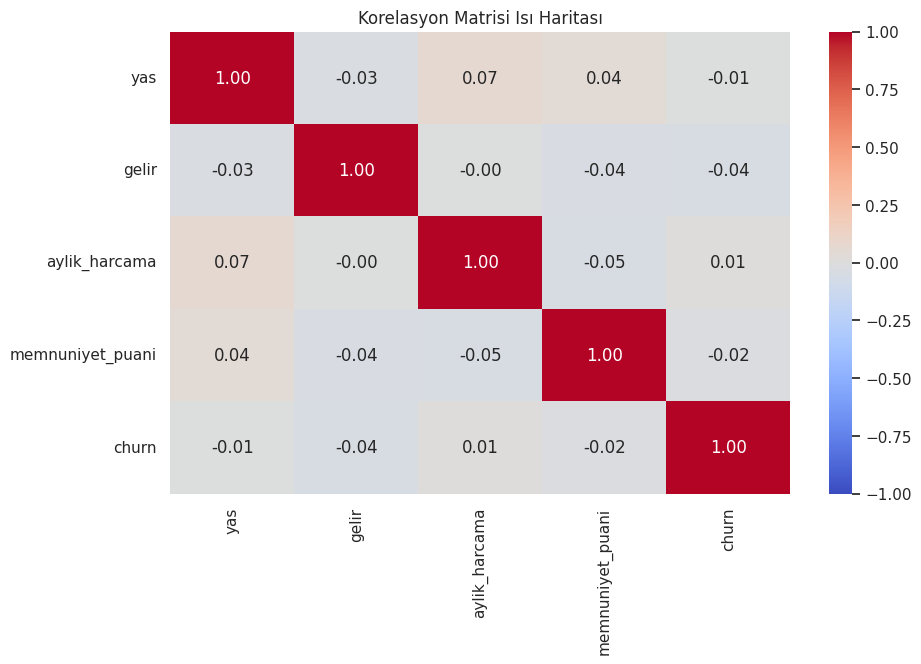

In [13]:
#korelasyon
korelasyon_kolonlari = [
    "yas",
    "gelir",
    "aylik_harcama",
    "memnuniyet_puani",
    "churn",
]
korelasyon = df[korelasyon_kolonlari].corr()
print(korelasyon)
# heatmap
sns.heatmap(korelasyon, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Korelasyon Matrisi Isı Haritası")
plt.show()